In [1]:
from src.material.textures.noise.FBM import FBMNoise
from src.material.material.phong_material import PhongMaterial
from src import Sphere, Scene, Color, Square, PointLight, AmbientLight, Vertex, Camera, Vector
from src.scene.object import Object

WHITE = Color.custom_rgb(255, 255, 255)

def scene_showcase() -> Scene:
    cam = Camera(
        origin=Vertex(0, 3.5, 8),
        direction=Vector(0, -0.35, -1),
        up_hint=Vector(0, 1, 0),
        fov_deg=50,
        aspect_ratio=16/9,
    )

    lights = [
        AmbientLight(intensity=0.12),
        PointLight(position=Vertex(0, 8, 4),   intensity=1.2),
        PointLight(position=Vertex(-6, 4, 2),  intensity=600.0, falloff=0.015),
        PointLight(position=Vertex(6, 4, 2),   intensity=600.0, falloff=0.015),
    ]

    ground_mat = PhongMaterial(
        "ground",
        base_color=Color.custom_rgb(230, 230, 230),
        spec_color=WHITE,
        shininess=20,
        reflectivity=0.7,
    )
    ground = Object(Square(), ground_mat).scale(6, 2.5, 1.0).rotate_x(-92).rotate_y(15).translate(0, -2.3, 0)

    ellipsoid_mat = PhongMaterial(
        "ellipsoid",
        base_color=Color.custom_rgb(100, 180, 255),
        spec_color=WHITE,
        shininess=120,
    )
    ellipsoid = (
        Object(Sphere(), ellipsoid_mat)
        .scale(0.7, 1.6, 0.7)
        .rotate_y(20)
        .translate(-2.5, 0.5, 0.0)
    )

    gold_mat = PhongMaterial(
        "gold",
        base_color=Color.custom_rgb(255, 200, 60),
        spec_color=WHITE,
        shininess=200,
        reflectivity=0.4,
    )
    disc = (
        Object(Sphere(), gold_mat)
        .scale(1.4, 0.5, 1.4)
        .translate(0.0, 0.5, 0.5)
    )

    dark_green = Color.custom_rgb(20, 80, 40)

    green_mat = PhongMaterial(
        "green_mirror",
        base_color=dark_green,
        spec_color=WHITE,
        shininess=300,
        reflectivity=0.2,
    )

    green_sphere = (
        Object(Sphere(), green_mat)
        .scale(2.4, 0.7, 1.1)
        .rotate_y(-15)
        .rotate_x(10)
        .rotate_z(5)
        .translate(0.0, 1.0, -1.0)
    )

    red_sphere = (
        Object(
            Sphere(),
            PhongMaterial(
                base_color=Color.custom_rgb(210, 40, 45),
                spec_color=WHITE,
                shininess=180,

                reflectivity=0.18,
                transparency=0.65,

                normal_noise=FBMNoise(
                    strength=0.18,
                    scale=3.0,
                    octaves=7,
                    lacunarity=2.15,
                    gain=0.48
                ),
                ior=1.52
            ),
        )
        .scale(1.2, 1.2, 3.2)
        .rotate_y(30)
        .rotate_x(-10)
        .rotate_z(-20)
        .translate(0.0, 1.0, 1.0)
    )

    material = PhongMaterial(
        "diamond",
        base_color=Color.custom_rgb(200, 220, 255),
        spec_color=WHITE,
        shininess=300,
        reflectivity=0.1,
        transparency=0.9,
        ior=2.42,
    )

    dia_ball = (
        Object(Sphere(), material)
        .scale(0.5, 0.6, 0.5)
        .rotate_y(15)
        .rotate_x(-10)
        .rotate_z(5)
        .translate(2.0, 3, -0.5)
    )

    noisy_diamond_mat = PhongMaterial(
        "noisy_diamond",
        base_color=Color.custom_rgb(200, 220, 255),
        spec_color=WHITE,
        shininess=300,
        reflectivity=0.1,
        transparency=0.9,
        ior=2.42,
        normal_noise=FBMNoise(
            strength=0.3,
            scale=5.0,
            octaves=6,
            lacunarity=2.0,
            gain=0.5
        )
    )

    noisy_dia_ball = (
        Object(Sphere(), noisy_diamond_mat)
        .scale(0.5, 0.6, 0.5)
        .translate(2.0, 3, -1.5)
    )

    return Scene(
        camera=cam,
        objects=[ground, ellipsoid, disc, green_sphere, red_sphere, dia_ball, noisy_dia_ball],
        lights=lights,
        skybox_path="./skybox/shanghai_4k.hdr"
    )

Scene validation passed.


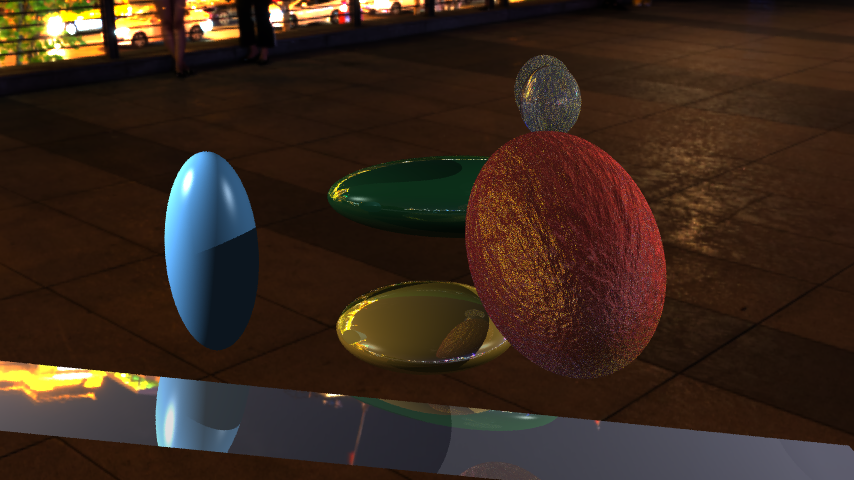

In [2]:
from src.render import LinearRayCaster
from src.render.loops.progress import PreviewConfig, ProgressDisplay
from src import ipynb_display_images, Resolution
from src.render.render_config import RenderConfig

scene = scene_showcase()
scene.validate()

preview_configuration = PreviewConfig(
    progress_display=ProgressDisplay.TQDM_IMAGE_PREVIEW,
)

rt = LinearRayCaster(
    scene=scene,
    render_config=RenderConfig(
        resolution=Resolution.R480p,
        samples_per_pixel=8,
        max_depth=10,
    ),
    preview_config=preview_configuration,
)

img = rt.render("scene_nonuniform_scale_normals.png")

ipynb_display_images(img)